In [1]:
import os
import numpy as np
import pandas as pd

from dekef.base_density import *
from dekef.kernel_function import *
from dekef.data_median_dist import *
from dekef.negloglik_params import *

from dekef.negloglik_grid_points import *
from dekef.scorematching_penalized_grid_points import *

from dekef.plot_density_1d import *

from IPython.display import Markdown as md

from datetime import datetime as dt

import warnings
warnings.filterwarnings('ignore')
np.random.seed(1989)

In [2]:
df = np.load('../data/geyser.npy').astype(np.float64)
waiting = df[:, 0].reshape(-1, 1)
# waiting = waiting[waiting != 108.0]

bw = 7.
kernel_type = 'gaussian_poly2'

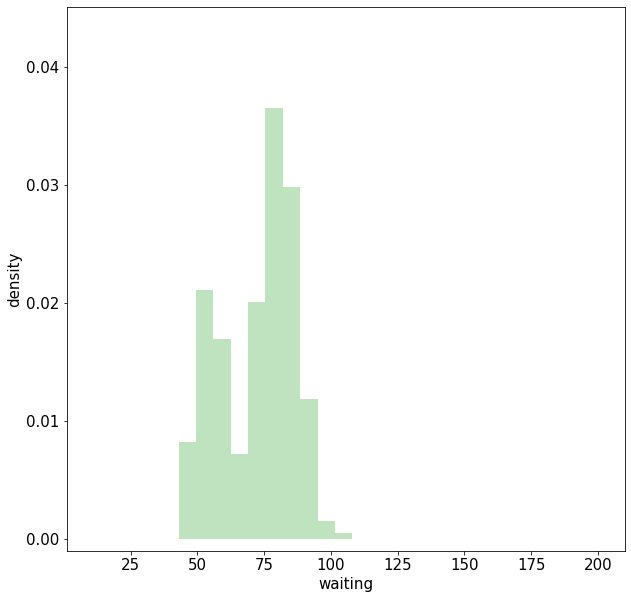

In [3]:
# set plot parameters
font_size = 15
xlimit = (1., 210.)
plot_pts_cnt = 3000
ylimit = (-0.001, 0.0451)

# plot the histogram of waiting variable 
ax = pd.Series(waiting.flatten()).hist(grid = False, figsize = (10, 10), 
                                       bins = 'fd', density = True, color = 'tab:green', alpha = 0.3)
ax.set_xlim(xlimit)
ax.set_ylim(ylimit)
# ax.set_title('Histogram of Waiting Variable', fontsize = font_size)
ax.set_xlabel('waiting', fontsize = font_size)
ax.set_ylabel('density', fontsize = font_size)
ax.tick_params(axis = 'both', labelsize = font_size)

# plt.savefig(f'../plots/histogram.pdf', bbox_inches = 'tight')

In [4]:
108 in waiting

True

In [5]:
base_density = BasedenGamma(waiting, 26., 3.)
base_density.a, base_density.scale

(26.0, 3.0)

In [8]:
seed_no = 1
grid_points = np.unique(waiting) # np.arange(1., 201., gap).reshape(-1, 1)
xlimit = (1., 210.)
plot_pts_cnt = 3000

new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)

ml_folder = (f'../data/data=geyser-waiting-PenML-bw={bw}-kernel={kernel_type}-' + 
             f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}-baseden=Gamma-{base_density.a}-{base_density.scale}-' + 
             f'grid_points=data-seed={seed_no}-with108={108 in waiting}')

if not os.path.isdir(ml_folder):
    os.mkdir(ml_folder)

file_name_newdata = f'/new_data.npy'
np.save(ml_folder + file_name_newdata, new_data)

file_name_grid_points = f'/grid_points.npy'
np.save(ml_folder + file_name_grid_points, grid_points)

In [9]:
nll_pen = NegLogLikGridPoints(
    data = waiting, 
    grid_points = grid_points, 
    base_density = base_density,
    kernel_type = 'gaussian_poly2', 
    kernel_r1 = 1.0, 
    kernel_r2 = 0.0, 
    kernel_c = 0.0, 
    kernel_bw = bw
)

In [14]:
0.05 / np.sqrt(200) * np.sqrt(len(grid_points))

0.025495097567963924

In [22]:
# set parameters for computing the density estimate
bmc_params = batch_montecarlo_params(
    mc_batch_size = 5000, 
    mc_tol = 5e-3)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.4, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05 / np.sqrt(200) * np.sqrt(len(grid_points))
)

ml_log_pen_param_list = [-np.inf, -15., -14., -13., -12., -11., -10., -9.5, -9., -8.5, -8., -7.5, -7., -6.5, -6.]

**************************************************
log penalty = -inf
start time = 13:06:11
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.4066390580005859, Relative Error = 0.7875250846171213
Iter = 3, GradNorm = 0.323415439219588, Relative Error = 0.6263485175039987
Iter = 4, GradNorm = 0.24762629405691358, Relative Error = 0.47957006181219825
Iter = 5, GradNorm = 0.1952164183260281, Relative Error = 0.37806950251354143
Iter = 6, GradNorm = 0.17286274091253784, Relative Error = 0.3347778379520487
Iter = 7, GradNorm = 0.14357876693611796, Relative Error = 0.27806448582817966
Iter = 8, GradNorm = 0.1321002384688481, Relative Error = 0.25583438046910784
Iter = 9, GradNorm = 0.08888930932850769, Relative Error = 0.1721491319468619
Iter = 10, GradNorm = 0.07132321240800732, Relative Error = 0.13812942407194923
Iter = 11, GradNorm = 0.06683601039346597, Relative Error = 0.1294392009449059
Iter = 12, GradNorm = 0.10416441066112689, Relative Error = 0.20

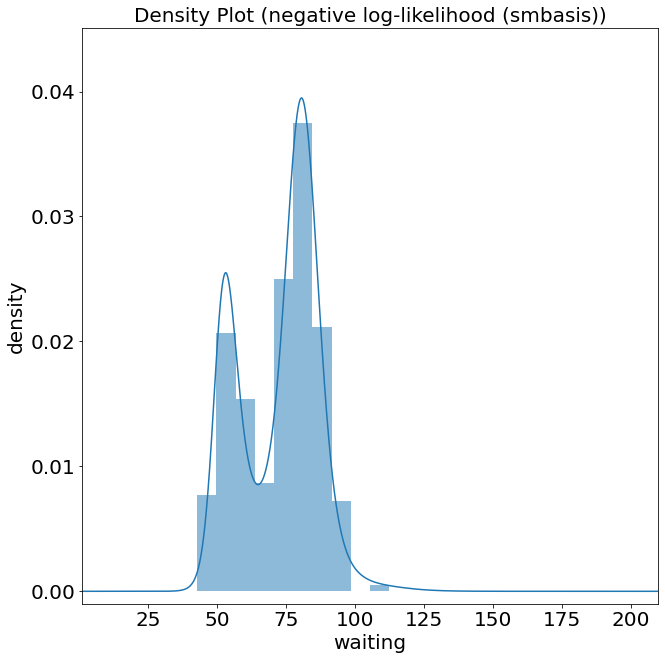

loss_val=-0.2653605955678804
3.5948866090583866
**************************************************
log penalty = -15.0
start time = 13:08:56
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.4066385879396954, Relative Error = 0.7875241742649668
Iter = 3, GradNorm = 0.32341468848621985, Relative Error = 0.6263470635822771
Iter = 4, GradNorm = 0.24762540953445306, Relative Error = 0.4795683487853459
Iter = 5, GradNorm = 0.1952154709200589, Relative Error = 0.378067667702174
Iter = 6, GradNorm = 0.17286181358779382, Relative Error = 0.334776042031359
Iter = 7, GradNorm = 0.14357778097462537, Relative Error = 0.2780625763475417
Iter = 8, GradNorm = 0.13209908289634506, Relative Error = 0.25583214250815617
Iter = 9, GradNorm = 0.0888882209353881, Relative Error = 0.17214702409011096
Iter = 10, GradNorm = 0.07132214649155504, Relative Error = 0.1381273597450535
Iter = 11, GradNorm = 0.06683484729776486, Relative Error = 0.12943694841401293
Iter = 12, GradNo

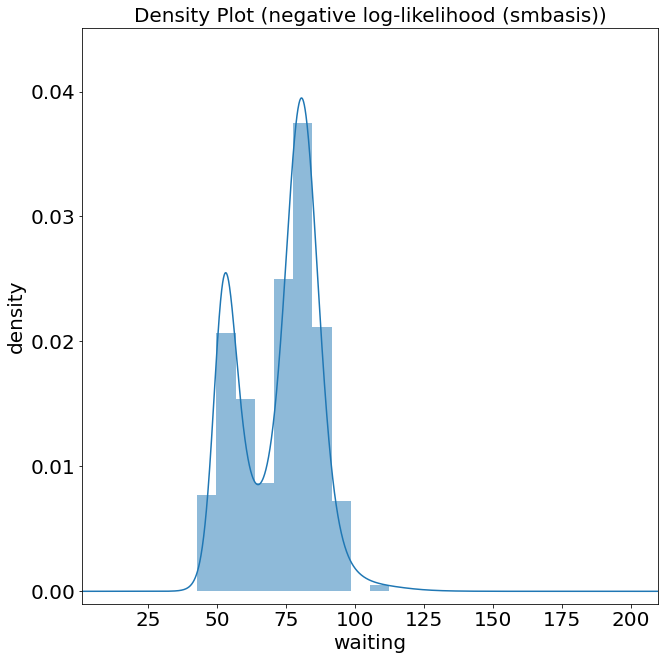

loss_val=-0.2653600682648858
3.5948132188431345
**************************************************
log penalty = -14.0
start time = 13:11:42
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.4066377802428614, Relative Error = 0.787522610023891
Iter = 3, GradNorm = 0.32341339851791323, Relative Error = 0.6263445653411961
Iter = 4, GradNorm = 0.2476238896835352, Relative Error = 0.479565405337836
Iter = 5, GradNorm = 0.19521384302368786, Relative Error = 0.37806451500643035
Iter = 6, GradNorm = 0.1728602202039155, Relative Error = 0.33477295617487546
Iter = 7, GradNorm = 0.14357608684505596, Relative Error = 0.27805929538004426
Iter = 8, GradNorm = 0.13209709733504324, Relative Error = 0.25582829713398103
Iter = 9, GradNorm = 0.08888635082016358, Relative Error = 0.17214340229672576
Iter = 10, GradNorm = 0.07132031501122313, Relative Error = 0.13812381277465066
Iter = 11, GradNorm = 0.06683284884565052, Relative Error = 0.12943307807460633
Iter = 12, Gr

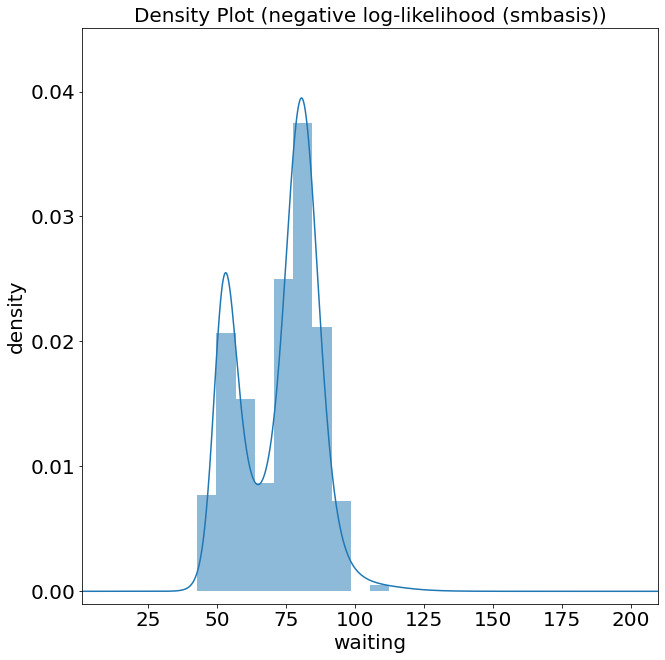

loss_val=-0.2653591621901088
3.594687122947825
**************************************************
log penalty = -13.0
start time = 13:14:28
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.40663558469684924, Relative Error = 0.7875183579789263
Iter = 3, GradNorm = 0.32340989204094306, Relative Error = 0.6263377744574423
Iter = 4, GradNorm = 0.24761975835121197, Relative Error = 0.4795574043163566
Iter = 5, GradNorm = 0.1952094180325811, Relative Error = 0.3780559452652134
Iter = 6, GradNorm = 0.1728558890740591, Relative Error = 0.3347645682117924
Iter = 7, GradNorm = 0.14357148191603472, Relative Error = 0.278050377158723
Iter = 8, GradNorm = 0.13209170026218114, Relative Error = 0.2558178447925771
Iter = 9, GradNorm = 0.0888812676450913, Relative Error = 0.1721335578713068
Iter = 10, GradNorm = 0.07131533694384921, Relative Error = 0.13811417190800804
Iter = 11, GradNorm = 0.06682741696296088, Relative Error = 0.1294225583181033
Iter = 12, GradNorm

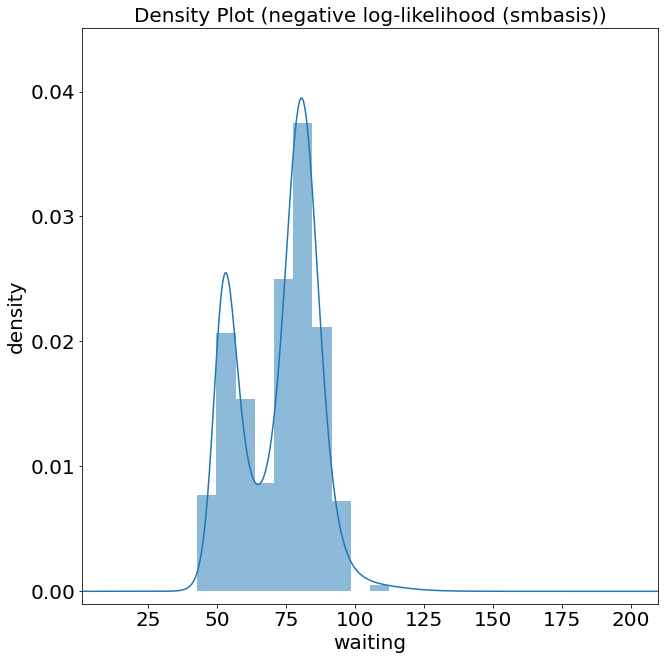

loss_val=-0.26535669909821147
3.5943444173961736
**************************************************
log penalty = -12.0
start time = 13:17:12
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.40662961659595087, Relative Error = 0.7875067997454697
Iter = 3, GradNorm = 0.3234003605993196, Relative Error = 0.6263193152139845
Iter = 4, GradNorm = 0.24760852860105373, Relative Error = 0.4795356560121305
Iter = 5, GradNorm = 0.1951973903247935, Relative Error = 0.3780326515815231
Iter = 6, GradNorm = 0.1728441168516674, Relative Error = 0.33474176931863947
Iter = 7, GradNorm = 0.14355896584422323, Relative Error = 0.27802613767577494
Iter = 8, GradNorm = 0.13207703128764936, Relative Error = 0.2557894358505876
Iter = 9, GradNorm = 0.08886745254508735, Relative Error = 0.17210680260128158
Iter = 10, GradNorm = 0.07130180820025744, Relative Error = 0.13808797121544727
Iter = 11, GradNorm = 0.06681265507242576, Relative Error = 0.12939396942861014
Iter = 12, G

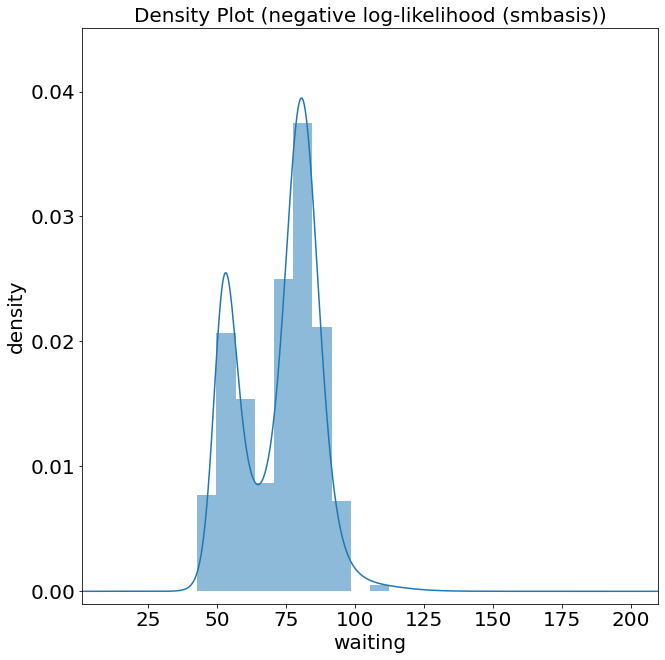

loss_val=-0.2653500027960696
3.593413280161421
**************************************************
log penalty = -11.0
start time = 13:19:57
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.4066133937038839, Relative Error = 0.7874753813802231
Iter = 3, GradNorm = 0.3233744525705494, Relative Error = 0.6262691399488494
Iter = 4, GradNorm = 0.24757800574919217, Relative Error = 0.47947654336413936
Iter = 5, GradNorm = 0.1951647005395838, Relative Error = 0.37796934230181456
Iter = 6, GradNorm = 0.17281212408952334, Relative Error = 0.3346798099415975
Iter = 7, GradNorm = 0.14352495414715075, Relative Error = 0.27796026829090403
Iter = 8, GradNorm = 0.1320371701086355, Relative Error = 0.2557122379578663
Iter = 9, GradNorm = 0.08882991695745596, Relative Error = 0.1720341086083068
Iter = 10, GradNorm = 0.07126505576808162, Relative Error = 0.13801679393503188
Iter = 11, GradNorm = 0.06677255393000071, Relative Error = 0.12931630680629144
Iter = 12, Grad

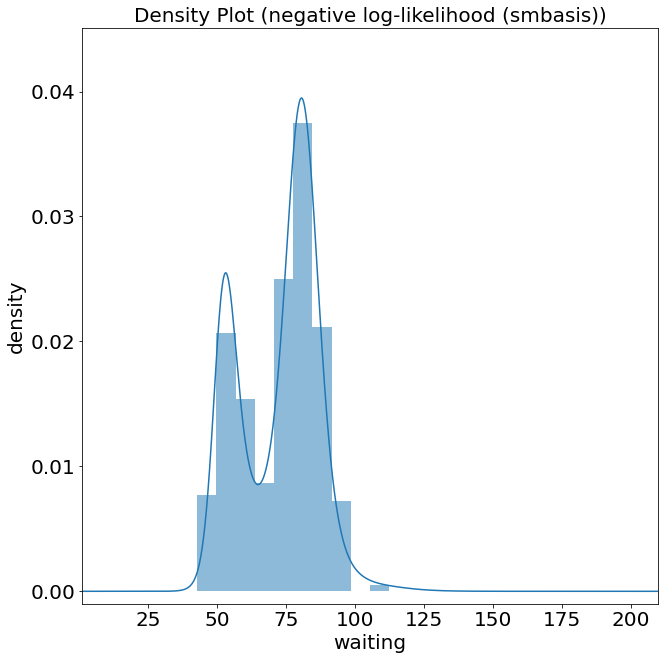

loss_val=-0.26533179356306436
3.5908853829590885
**************************************************
log penalty = -10.0
start time = 13:22:43
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.4065692959626666, Relative Error = 0.7873899786706203
Iter = 3, GradNorm = 0.32330403549137743, Relative Error = 0.6261327654045395
Iter = 4, GradNorm = 0.24749505653044165, Relative Error = 0.479315898218942
Iter = 5, GradNorm = 0.19507587679517466, Relative Error = 0.3777973201473866
Iter = 6, GradNorm = 0.17272521382030398, Relative Error = 0.3345114935544369
Iter = 7, GradNorm = 0.14343257842103194, Relative Error = 0.2777813671251233
Iter = 8, GradNorm = 0.13192891387899056, Relative Error = 0.2555025815199662
Iter = 9, GradNorm = 0.08872801571001795, Relative Error = 0.1718367596647356
Iter = 10, GradNorm = 0.0711653184949036, Relative Error = 0.1378236358924051
Iter = 11, GradNorm = 0.06666373849580298, Relative Error = 0.12910556737450746
Iter = 12, GradN

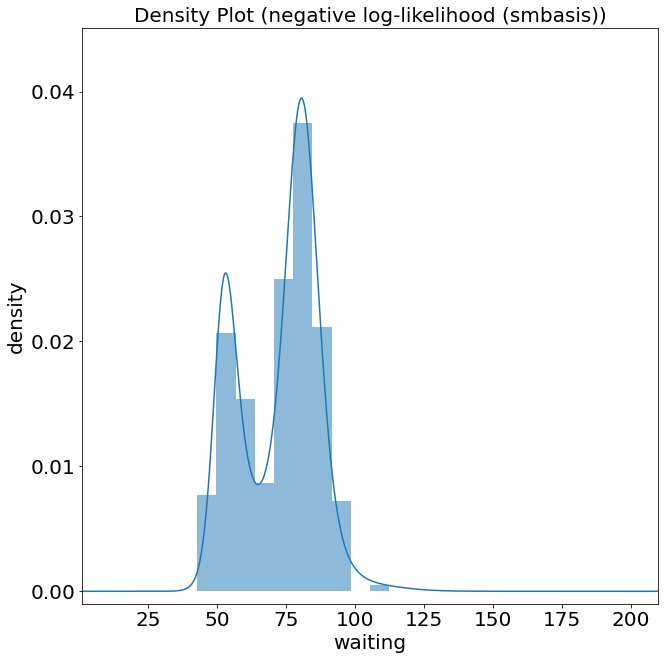

loss_val=-0.26528224616257945
3.5840373923605267
**************************************************
log penalty = -9.5
start time = 13:25:27
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.40652404111990675, Relative Error = 0.7873023350388231
Iter = 3, GradNorm = 0.32323178165674266, Relative Error = 0.6259928336736467
Iter = 4, GradNorm = 0.24740996005629412, Relative Error = 0.47915109455169674
Iter = 5, GradNorm = 0.194984775540151, Relative Error = 0.3776208872097244
Iter = 6, GradNorm = 0.17263610479967834, Relative Error = 0.33433891891452544
Iter = 7, GradNorm = 0.14333789469770175, Relative Error = 0.2775979961336743
Iter = 8, GradNorm = 0.1318179630116397, Relative Error = 0.2552877064619025
Iter = 9, GradNorm = 0.08862363738144946, Relative Error = 0.17163461343598357
Iter = 10, GradNorm = 0.07106321433752857, Relative Error = 0.1376258939795355
Iter = 11, GradNorm = 0.06655235504933274, Relative Error = 0.1288898545540575
Iter = 12, Grad

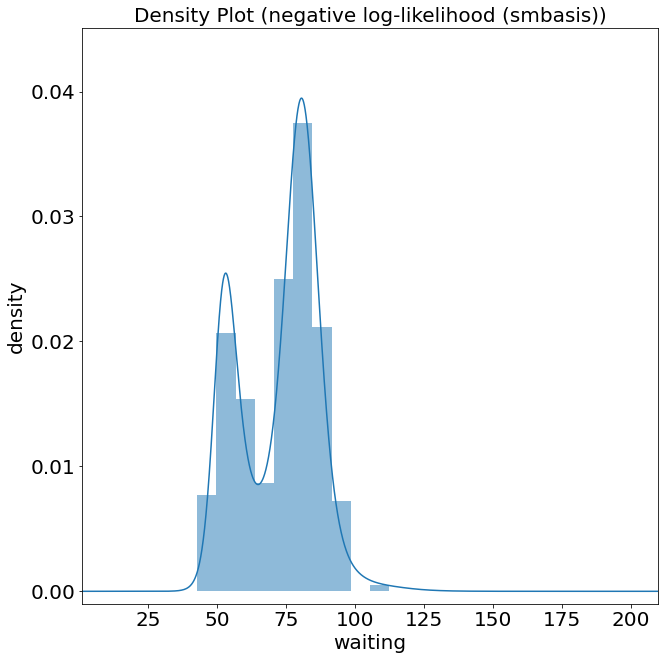

loss_val=-0.2652313237433852
3.5770451856076466
**************************************************
log penalty = -9.0
start time = 13:28:11
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.4064494306900942, Relative Error = 0.7871578393641075
Iter = 3, GradNorm = 0.3231126829443735, Relative Error = 0.6257621789401898
Iter = 4, GradNorm = 0.24726972857535934, Relative Error = 0.47887951264947576
Iter = 5, GradNorm = 0.19483469693389013, Relative Error = 0.3773302346893395
Iter = 6, GradNorm = 0.17248937379335158, Relative Error = 0.3340547495857315
Iter = 7, GradNorm = 0.1431820482791395, Relative Error = 0.2772961732724642
Iter = 8, GradNorm = 0.1316353637074016, Relative Error = 0.25493407212773844
Iter = 9, GradNorm = 0.0884519861888668, Relative Error = 0.17130218196560795
Iter = 10, GradNorm = 0.07089543048713468, Relative Error = 0.13730095226924202
Iter = 11, GradNorm = 0.06636935442166639, Relative Error = 0.1285354429894219
Iter = 12, GradNo

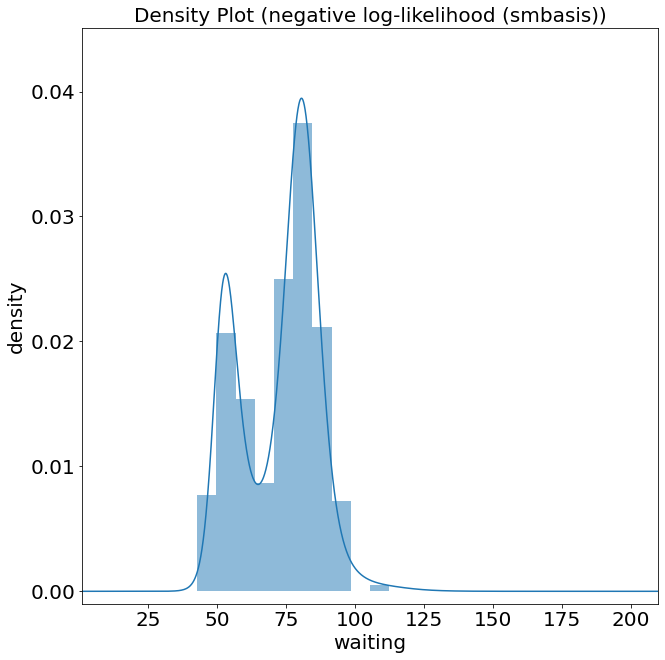

loss_val=-0.26514720889213095
3.5655952003538287
**************************************************
log penalty = -8.5
start time = 13:30:54
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.40632642484961123, Relative Error = 0.7869196178184178
Iter = 3, GradNorm = 0.32291639771862174, Relative Error = 0.6253820395119231
Iter = 4, GradNorm = 0.24703871313754489, Relative Error = 0.47843211231093663
Iter = 5, GradNorm = 0.19458759044677237, Relative Error = 0.37685167132129094
Iter = 6, GradNorm = 0.17224795733800505, Relative Error = 0.33358720592339974
Iter = 7, GradNorm = 0.14292580839625516, Relative Error = 0.27679992154386
Iter = 8, GradNorm = 0.13133519750700878, Relative Error = 0.2543527496804412
Iter = 9, GradNorm = 0.08817017343234715, Relative Error = 0.17075640405628573
Iter = 10, GradNorm = 0.07062031361714899, Relative Error = 0.1367681420729456
Iter = 11, GradNorm = 0.06606937161794967, Relative Error = 0.12795447572070384
Iter = 12, G

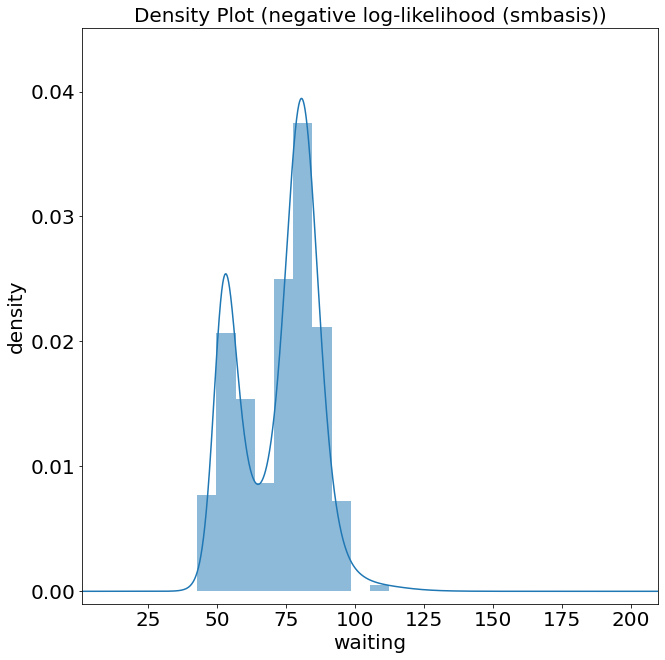

loss_val=-0.26500811833610505
3.546927658104146
**************************************************
log penalty = -8.0
start time = 13:33:38
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.40612363872681084, Relative Error = 0.7865268883071338
Iter = 3, GradNorm = 0.3225929829237925, Relative Error = 0.6247556922423897
Iter = 4, GradNorm = 0.24665834161283412, Relative Error = 0.47769545873256014
Iter = 5, GradNorm = 0.19418108019263508, Relative Error = 0.37606439568706806
Iter = 6, GradNorm = 0.1718512909006499, Relative Error = 0.3328189944997877
Iter = 7, GradNorm = 0.14250525830803007, Relative Error = 0.27598545540417424
Iter = 8, GradNorm = 0.13084271620132074, Relative Error = 0.2533989766124007
Iter = 9, GradNorm = 0.08770877152314657, Relative Error = 0.1698628214787234
Iter = 10, GradNorm = 0.07017081738669974, Relative Error = 0.13589761684927387
Iter = 11, GradNorm = 0.0655794777031403, Relative Error = 0.12700571357126686
Iter = 12, Gra

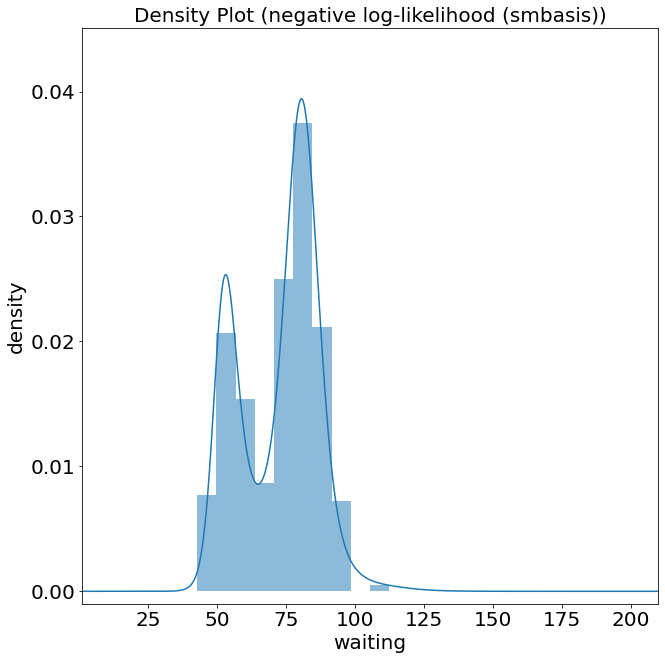

loss_val=-0.2647777764580088
3.5167114919596463
**************************************************
log penalty = -7.5
start time = 13:36:23
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.4057893451026899, Relative Error = 0.7858794723507884
Iter = 3, GradNorm = 0.32206031884907693, Relative Error = 0.6237240984683545
Iter = 4, GradNorm = 0.24603259606063835, Relative Error = 0.47648359698626164
Iter = 5, GradNorm = 0.1935132981299634, Relative Error = 0.37477112315196753
Iter = 6, GradNorm = 0.1712009883999154, Relative Error = 0.3315595740829793
Iter = 7, GradNorm = 0.14181708025360085, Relative Error = 0.27465268259279996
Iter = 8, GradNorm = 0.1300372651630358, Relative Error = 0.2518390848986062
Iter = 9, GradNorm = 0.08695677141272114, Relative Error = 0.16840644649716904
Iter = 10, GradNorm = 0.06944078681918475, Relative Error = 0.13448378959106078
Iter = 11, GradNorm = 0.06478444978940054, Relative Error = 0.12546600799522262
Iter = 12, Gra

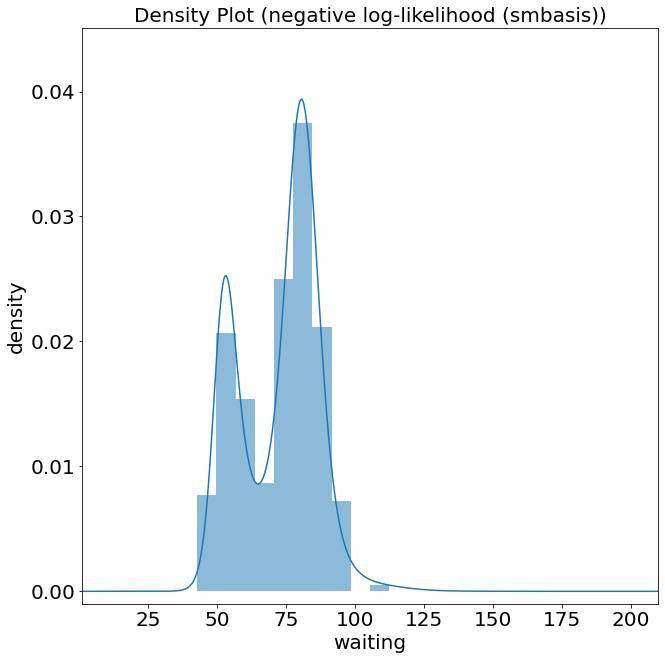

loss_val=-0.26439561812610846
3.4683748692614964
**************************************************
log penalty = -7.0
start time = 13:39:07
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.4052383084827029, Relative Error = 0.7848122970457007
Iter = 3, GradNorm = 0.3211836176702401, Relative Error = 0.6220262188464556
Iter = 4, GradNorm = 0.24500466442633606, Relative Error = 0.47449283409382115
Iter = 5, GradNorm = 0.19241892211768127, Relative Error = 0.3726516795207702
Iter = 6, GradNorm = 0.17013879539045718, Relative Error = 0.32950245826197005
Iter = 7, GradNorm = 0.1406964809585602, Relative Error = 0.27248245315397535
Iter = 8, GradNorm = 0.12872684895781106, Relative Error = 0.24930124301500198
Iter = 9, GradNorm = 0.08574040453684376, Relative Error = 0.16605074699412373
Iter = 10, GradNorm = 0.06826694173240995, Relative Error = 0.13221044070068344
Iter = 11, GradNorm = 0.06350771430386129, Relative Error = 0.12299339450298517
Iter = 12, 

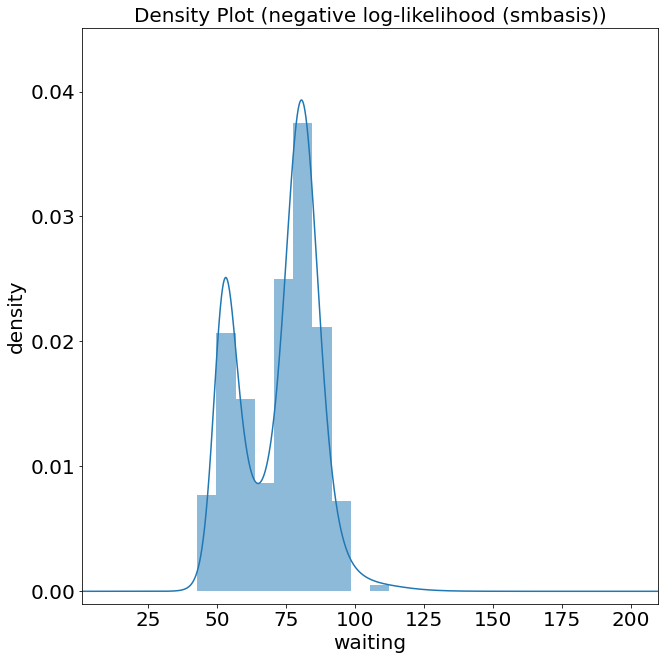

loss_val=-0.26376063442393427
3.3925164055387333
**************************************************
log penalty = -6.5
start time = 13:41:51
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.4043301313886823, Relative Error = 0.7830534590080253
Iter = 3, GradNorm = 0.31974229537003873, Relative Error = 0.6192348552425565
Iter = 4, GradNorm = 0.24332005490165248, Relative Error = 0.4712303037677959
Iter = 5, GradNorm = 0.1906324707069675, Relative Error = 0.3691919152145468
Iter = 6, GradNorm = 0.168414400291298, Relative Error = 0.3261628764641568
Iter = 7, GradNorm = 0.13888658162802486, Relative Error = 0.26897727799830634
Iter = 8, GradNorm = 0.12661334005587754, Relative Error = 0.24520807674362075
Iter = 9, GradNorm = 0.08379768673038494, Relative Error = 0.1622883464700785
Iter = 10, GradNorm = 0.06641117662001815, Relative Error = 0.1286164387266681
Iter = 11, GradNorm = 0.061493502452308016, Relative Error = 0.1190925337085727
Iter = 12, GradN

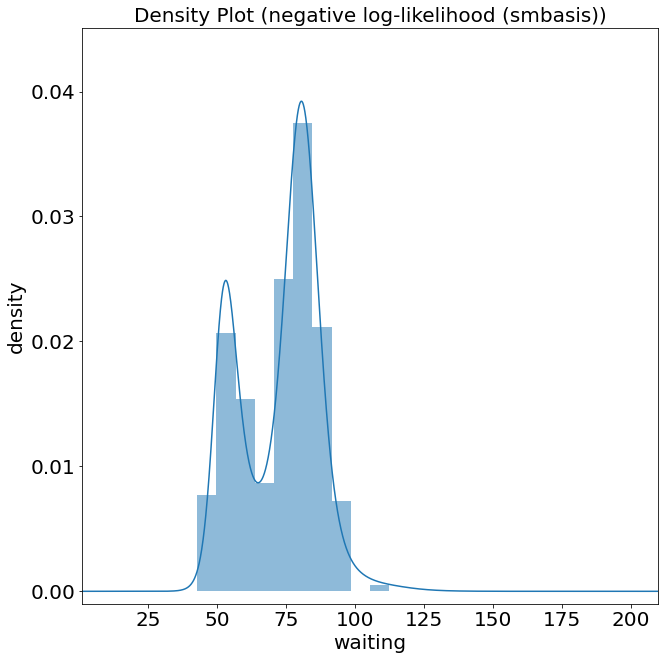

loss_val=-0.2627065144056724
3.2770709480498206
**************************************************
log penalty = -6.0
start time = 13:44:35
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.40283370055821316, Relative Error = 0.7801553684453938
Iter = 3, GradNorm = 0.3173771371328347, Relative Error = 0.6146543276118726
Iter = 4, GradNorm = 0.24057011366801723, Relative Error = 0.465904579000089
Iter = 5, GradNorm = 0.18773523962326616, Relative Error = 0.3635809388229382
Iter = 6, GradNorm = 0.1656432715536517, Relative Error = 0.32079611852326884
Iter = 7, GradNorm = 0.13600297063763087, Relative Error = 0.2633926792133819
Iter = 8, GradNorm = 0.12325343024349336, Relative Error = 0.23870104499828376
Iter = 9, GradNorm = 0.08076044582548766, Relative Error = 0.15640621745769925
Iter = 10, GradNorm = 0.06356180630528135, Relative Error = 0.12309815278224369
Iter = 11, GradNorm = 0.058411503437444466, Relative Error = 0.11312372307118725
Iter = 12, Gr

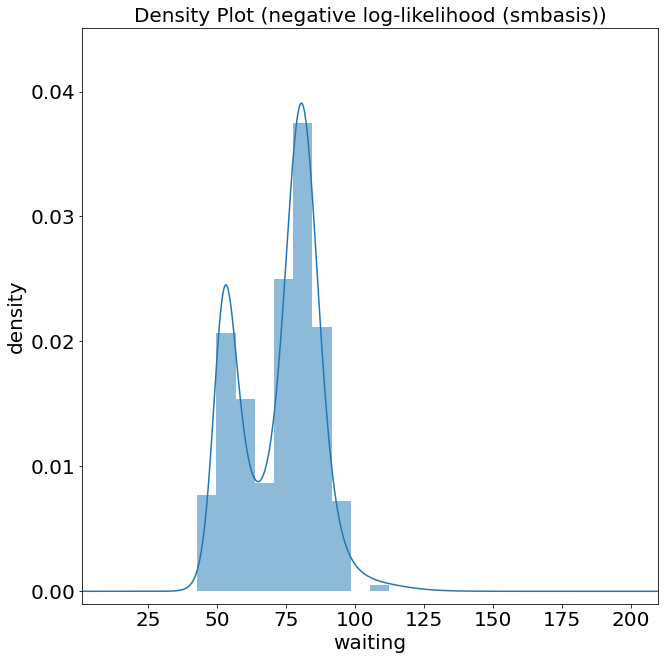

loss_val=-0.26097053855054586
3.109695377974784


In [23]:
waiting = waiting.reshape(-1, 1)
for log_pen_param in ml_log_pen_param_list: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))
    
    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    print(f'loss_val={loss_val}')

    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = -5.5
start time = 18:21:00
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.40036897960214274, Relative Error = 0.7753820208259328
Iter = 3, GradNorm = 0.31350803566808305, Relative Error = 0.6071611603952193
Iter = 4, GradNorm = 0.23611048610728624, Relative Error = 0.4572677584511873
Iter = 5, GradNorm = 0.18308735335315543, Relative Error = 0.35457952354778666
Iter = 6, GradNorm = 0.1612650156621256, Relative Error = 0.3123168879289354
Iter = 7, GradNorm = 0.13151299033378008, Relative Error = 0.2546970754607433
Iter = 8, GradNorm = 0.11803925267332115, Relative Error = 0.22860291115853673
Iter = 9, GradNorm = 0.07618233509504321, Relative Error = 0.14753993427745782
Iter = 10, GradNorm = 0.05940834990019884, Relative Error = 0.11505428428877147
Iter = 11, GradNorm = 0.053944632061325985, Relative Error = 0.10447287365266819
Iter = 12, GradNorm = 0.09413661441024589, Relative Error =

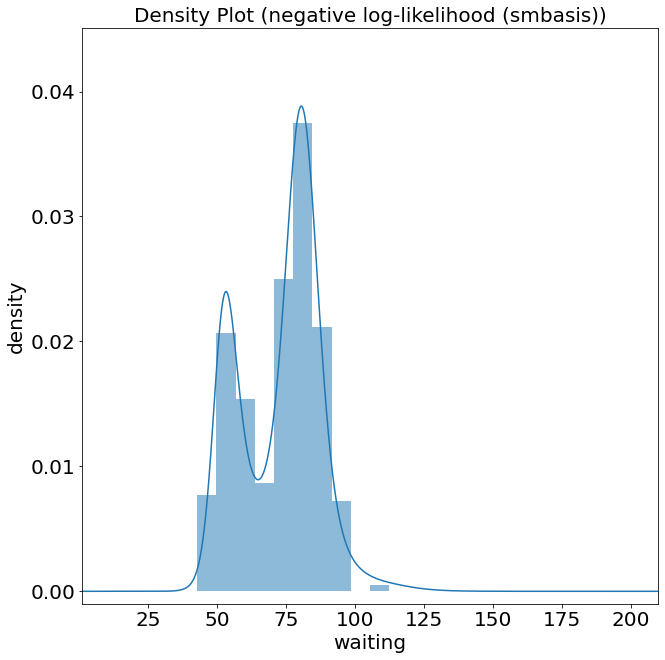

loss_val=-0.2581770307172916
2.8842816403479237
**************************************************
log penalty = -5.0
start time = 18:23:41
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.39631220947998824, Relative Error = 0.7675254016181504
Iter = 3, GradNorm = 0.307211529578854, Relative Error = 0.5949669149258006
Iter = 4, GradNorm = 0.22895731410757109, Relative Error = 0.4434144350344574
Iter = 5, GradNorm = 0.17576564413043647, Relative Error = 0.3403997993877051
Iter = 6, GradNorm = 0.1545426933006884, Relative Error = 0.2992979774668057
Iter = 7, GradNorm = 0.12479068317780696, Relative Error = 0.24167819444655808
Iter = 8, GradNorm = 0.11026860156499212, Relative Error = 0.2135537353570127
Iter = 9, GradNorm = 0.0697084594646995, Relative Error = 0.13500218279176604
Iter = 10, GradNorm = 0.0539161511484419, Relative Error = 0.1044177155637249
Iter = 11, GradNorm = 0.04809491043665141, Relative Error = 0.0931439016151326
Iter = 12, GradNorm

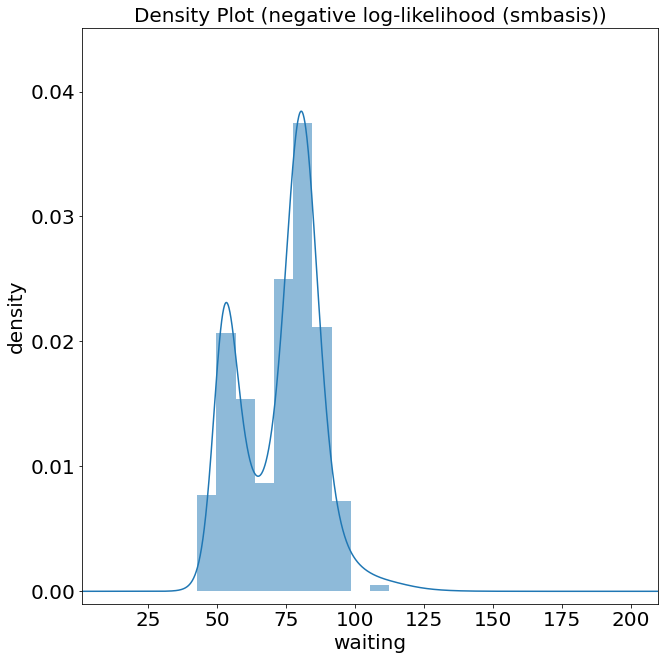

loss_val=-0.25293140780537127
2.5550302481349396
**************************************************
log penalty = -4.5
start time = 18:26:23
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.38964302712022136, Relative Error = 0.7546094057272814
Iter = 3, GradNorm = 0.2970546143875651, Relative Error = 0.5752963364653881
Iter = 4, GradNorm = 0.2176954804423316, Relative Error = 0.4216039956886411
Iter = 5, GradNorm = 0.16458274966399014, Relative Error = 0.3187422391074533
Iter = 6, GradNorm = 0.14471290217338595, Relative Error = 0.28026092990093626
Iter = 7, GradNorm = 0.11539250846686036, Relative Error = 0.22347704483029557
Iter = 8, GradNorm = 0.0994571335503182, Relative Error = 0.192615505013485
Iter = 9, GradNorm = 0.06154733164682106, Relative Error = 0.11919678301795335
Iter = 10, GradNorm = 0.04796907381411959, Relative Error = 0.09290019778280875
Iter = 11, GradNorm = 0.04186299083484665, Relative Error = 0.08107473876621779
Iter = 12, Gra

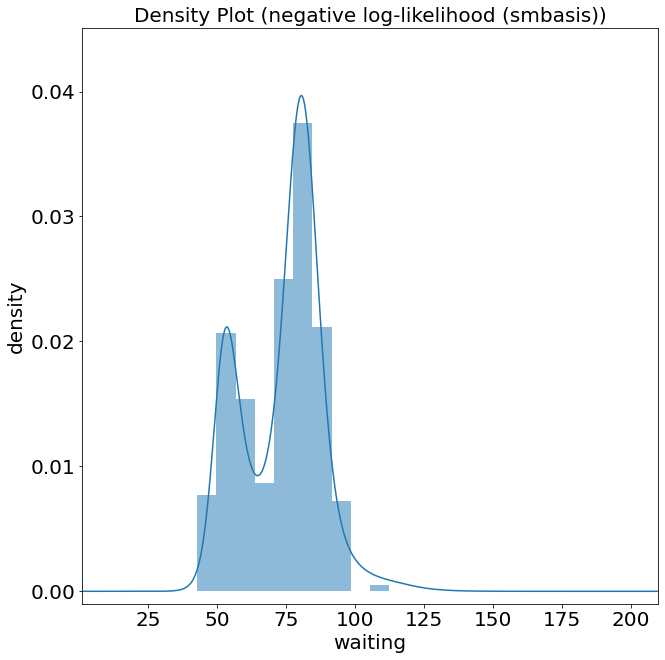

loss_val=-0.2532969032915322
2.389446164074135


In [33]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.4, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05 / np.sqrt(200) * np.sqrt(len(grid_points))
)

for log_pen_param in [-5.5, -5., -4.5]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    print(f'loss_val={loss_val}')
    
    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = -4.5
start time = 19:11:52
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.40539273019432703, Relative Error = 0.7851113607217565
Iter = 3, GradNorm = 0.32235048990918796, Relative Error = 0.6242860636415747
Iter = 4, GradNorm = 0.2453243621361858, Relative Error = 0.4751119826016877
Iter = 5, GradNorm = 0.19127297202315138, Relative Error = 0.3704323539852474
Iter = 6, GradNorm = 0.16630828572012052, Relative Error = 0.32208403056077706
Iter = 7, GradNorm = 0.1314966918972659, Relative Error = 0.25466551079093996
Iter = 8, GradNorm = 0.11716855925122587, Relative Error = 0.2269166665703197
Iter = 9, GradNorm = 0.07876743363965508, Relative Error = 0.15254641338966873
Iter = 10, GradNorm = 0.060107269006014825, Relative Error = 0.11640785895681889
Iter = 11, GradNorm = 0.05163412274823107, Relative Error = 0.0999981828759128
Iter = 12, GradNorm = 0.0875093000217559, Relative Error = 0.

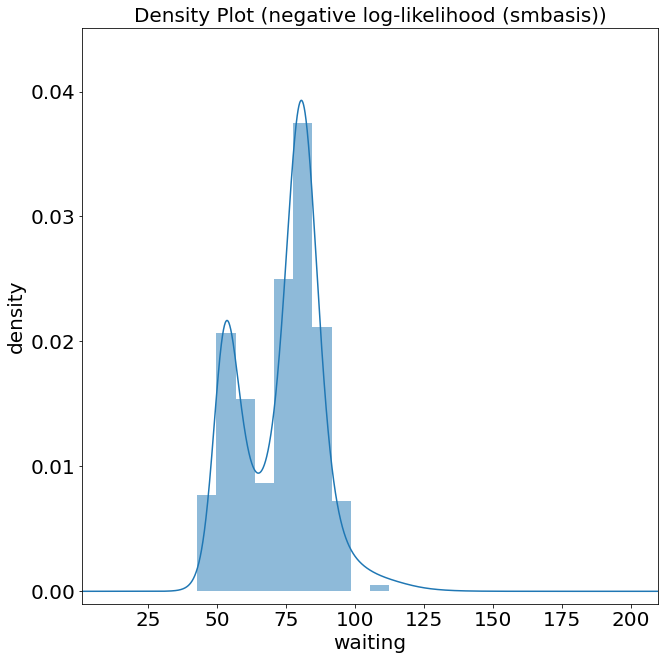

loss_val=-0.2536376100254456
2.3559882494601982
**************************************************
log penalty = -4.0
start time = 19:14:14
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.3957719089846084, Relative Error = 0.7664790186281966
Iter = 3, GradNorm = 0.30751558268742823, Relative Error = 0.595555765026023
Iter = 4, GradNorm = 0.22863924586079593, Relative Error = 0.44279844225652
Iter = 5, GradNorm = 0.17457841199624485, Relative Error = 0.3381005242232961
Iter = 6, GradNorm = 0.1513522750207423, Relative Error = 0.2931191946459117
Iter = 7, GradNorm = 0.1170553693594226, Relative Error = 0.22669745526396248
Iter = 8, GradNorm = 0.10188580311176561, Relative Error = 0.1973190330299284
Iter = 9, GradNorm = 0.06788655465259905, Relative Error = 0.13147375699723332
Iter = 10, GradNorm = 0.052220542972855166, Relative Error = 0.10113388449613842
Iter = 11, GradNorm = 0.04448504866686734, Relative Error = 0.0861527957688732
Iter = 12, GradNor

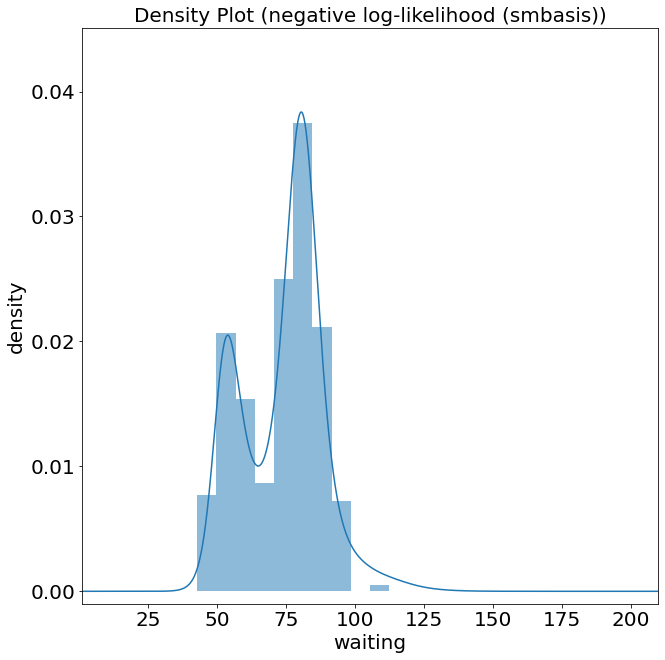

loss_val=-0.24817548545381457
2.0772849796440145


In [35]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.35, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05 / np.sqrt(200) * np.sqrt(len(grid_points))
)

for log_pen_param in [-4.5, -4.]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    print(f'loss_val={loss_val}')
    
    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = -3.5
start time = 18:34:25
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.39940229015791523, Relative Error = 0.773509863758417
Iter = 3, GradNorm = 0.31398501668541234, Relative Error = 0.6080849145419064
Iter = 4, GradNorm = 0.24187229944820146, Relative Error = 0.4684264812781661
Iter = 5, GradNorm = 0.17541471158382413, Relative Error = 0.3397201593530644
Iter = 6, GradNorm = 0.17665467181160627, Relative Error = 0.3421215513593005
Iter = 7, GradNorm = 0.12171176772596853, Relative Error = 0.23571535564877952
Iter = 8, GradNorm = 0.09521695508296492, Relative Error = 0.1844036846273349
Iter = 9, GradNorm = 0.09331324130486775, Relative Error = 0.1807168219792796
Iter = 10, GradNorm = 0.08381756431061166, Relative Error = 0.16232684275503204
Iter = 11, GradNorm = 0.047847409756790624, Relative Error = 0.0926645748263865
Iter = 12, GradNorm = 0.04327901023033998, Relative Error = 0.

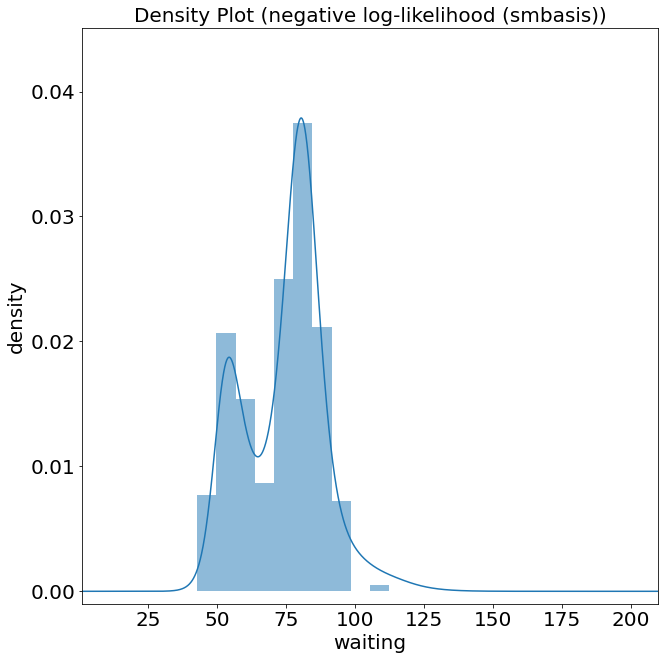

loss_val=-0.23494087471431696
1.8189143467280662
**************************************************
log penalty = -3.0
start time = 18:37:05
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.3772618901017652, Relative Error = 0.7306312467524447
Iter = 3, GradNorm = 0.2817404141227194, Relative Error = 0.5456378060755238
Iter = 4, GradNorm = 0.20645413499454313, Relative Error = 0.3998332352297007
Iter = 5, GradNorm = 0.1431859225233386, Relative Error = 0.2773036763994528
Iter = 6, GradNorm = 0.1294644075261759, Relative Error = 0.25072964951588655
Iter = 7, GradNorm = 0.09088629613807772, Relative Error = 0.17601663354377847
Iter = 8, GradNorm = 0.07794848326695894, Relative Error = 0.15096037793914932
Iter = 9, GradNorm = 0.08336160073856869, Relative Error = 0.16144379243413798
Iter = 10, GradNorm = 0.05044206566404145, Relative Error = 0.09768956338247123
Iter = 11, GradNorm = 0.04252278272951716, Relative Error = 0.08235253699404894
Iter = 12, Gr

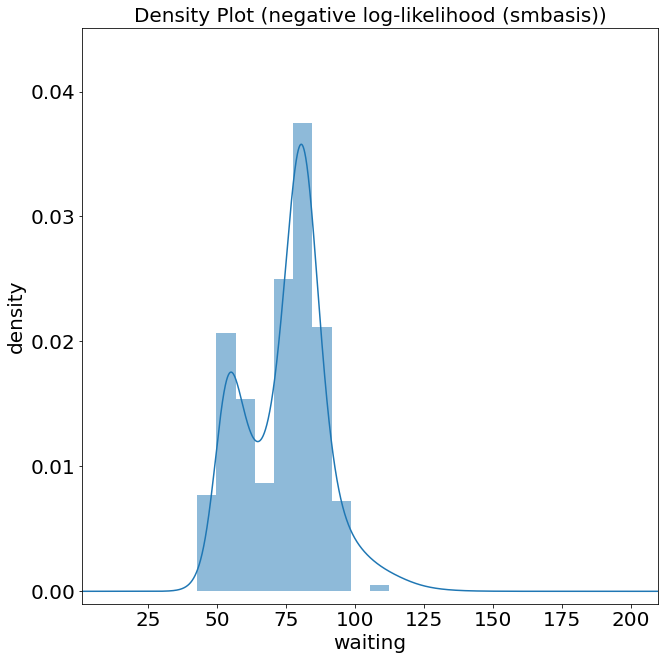

loss_val=-0.21398944129772343
1.5282816763205544
**************************************************
log penalty = -2.5
start time = 18:39:04
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.34153304617374924, Relative Error = 0.6614363175293839
Iter = 3, GradNorm = 0.23520519750807453, Relative Error = 0.4555145144706347
Iter = 4, GradNorm = 0.1602048575729029, Relative Error = 0.310263713073997
Iter = 5, GradNorm = 0.10717072684656062, Relative Error = 0.207554178743436
Iter = 6, GradNorm = 0.09619359574684373, Relative Error = 0.18629511390922296
Iter = 7, GradNorm = 0.06788941819633648, Relative Error = 0.13147930273240008
Iter = 8, GradNorm = 0.06336846897725398, Relative Error = 0.12272372245485938
Iter = 9, GradNorm = 0.07187480017440079, Relative Error = 0.13919766676496215
Iter = 10, GradNorm = 0.046814677065218066, Relative Error = 0.09066451387720839
Iter = 11, GradNorm = 0.039983365669498123, Relative Error = 0.0774345277774656
Iter = 12, 

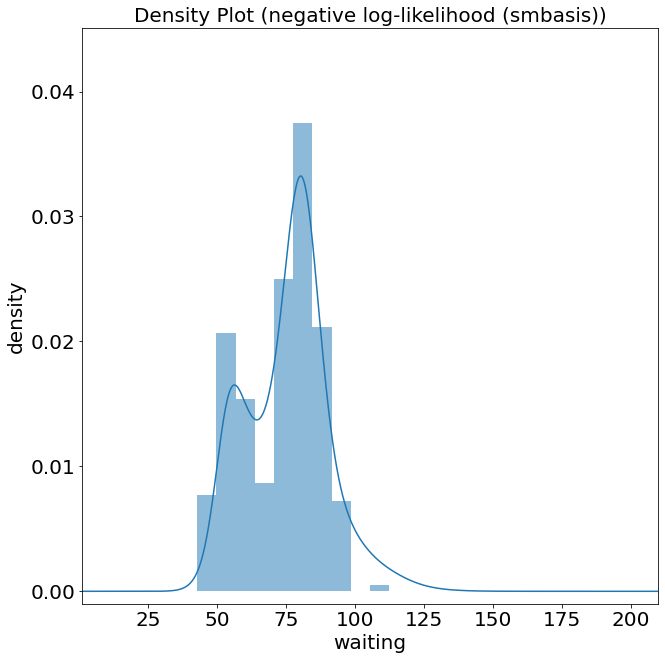

loss_val=-0.1899164930742563
1.2210403621982746
**************************************************
log penalty = -2.0
start time = 18:40:56
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.28558411606803297, Relative Error = 0.5530817828410851
Iter = 3, GradNorm = 0.17567172427853472, Relative Error = 0.34021790776204613
Iter = 4, GradNorm = 0.1091498177238857, Relative Error = 0.21138702185077018
Iter = 5, GradNorm = 0.07189770548149793, Relative Error = 0.13924202675339648
Iter = 6, GradNorm = 0.06931409932916995, Relative Error = 0.13423843791042192
Iter = 7, GradNorm = 0.05175059633211648, Relative Error = 0.1002237536055324
Iter = 8, GradNorm = 0.05382132743455447, Relative Error = 0.10423407345696299
Iter = 9, GradNorm = 0.06793576119334756, Relative Error = 0.1315690537583394
Iter = 10, GradNorm = 0.0485512742665262, Relative Error = 0.09402772710279104
Iter = 11, GradNorm = 0.037574179053121236, Relative Error = 0.07276873176847054
Iter = 12,

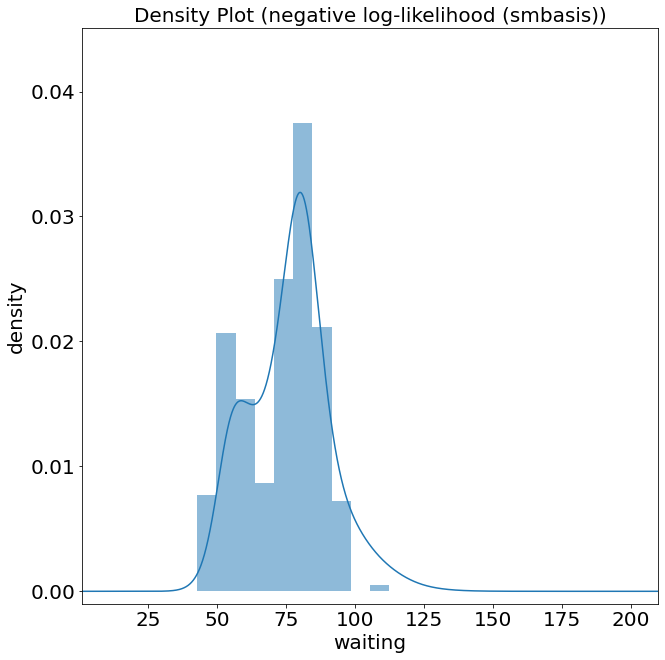

loss_val=-0.15509627073103274
0.9205100153376543
**************************************************
log penalty = -1.5
start time = 18:41:56
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.20840521063353246, Relative Error = 0.40361182210535507
Iter = 3, GradNorm = 0.11832082732959656, Relative Error = 0.22914822794659848
Iter = 4, GradNorm = 0.07299671209510489, Relative Error = 0.14137043832465865
Iter = 5, GradNorm = 0.04868194511417986, Relative Error = 0.09428079322698832
Iter = 6, GradNorm = 0.057597460957348835, Relative Error = 0.11154719258203212
Iter = 7, GradNorm = 0.04529130589277954, Relative Error = 0.08771424880091018
Iter = 8, GradNorm = 0.039898567955128666, Relative Error = 0.07727030270889373
Iter = 9, GradNorm = 0.06459823483718419, Relative Error = 0.1251053713492442
Iter = 10, GradNorm = 0.06954054346458947, Relative Error = 0.13467698515127025
Iter = 11, GradNorm = 0.06868200343042176, Relative Error = 0.13301427764752097
Iter

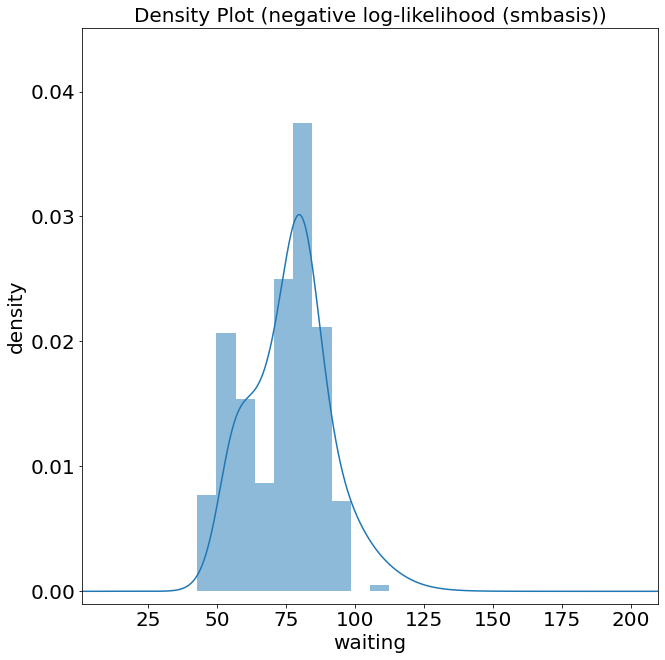

loss_val=-0.12096263779005105
0.6698293059743774


In [34]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.3, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05 / np.sqrt(200) * np.sqrt(len(grid_points))
)

for log_pen_param in [-3.5, -3., -2.5, -2., -1.5]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    print(f'loss_val={loss_val}')
    
    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = -1.0
start time = 19:16:35
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.21510778695862545, Relative Error = 0.41659249103943463
Iter = 3, GradNorm = 0.1252078326555914, Relative Error = 0.24248607473087083
Iter = 4, GradNorm = 0.07389678346655223, Relative Error = 0.1431135782641563
Iter = 5, GradNorm = 0.049713464190044236, Relative Error = 0.09627850380476341
Iter = 6, GradNorm = 0.05472524576752267, Relative Error = 0.1059846636859437
Iter = 7, GradNorm = 0.042544548192837574, Relative Error = 0.08239468948286156
Iter = 8, GradNorm = 0.044597807570705944, Relative Error = 0.08637117239438344
Iter = 9, GradNorm = 0.06300893361066813, Relative Error = 0.12202742160912763
Iter = 10, GradNorm = 0.06043641519961275, Relative Error = 0.1170453060462331
Iter = 11, GradNorm = 0.06203473574052799, Relative Error = 0.12014072320910618
Iter = 12, GradNorm = 0.04330721461199259, Relative Err

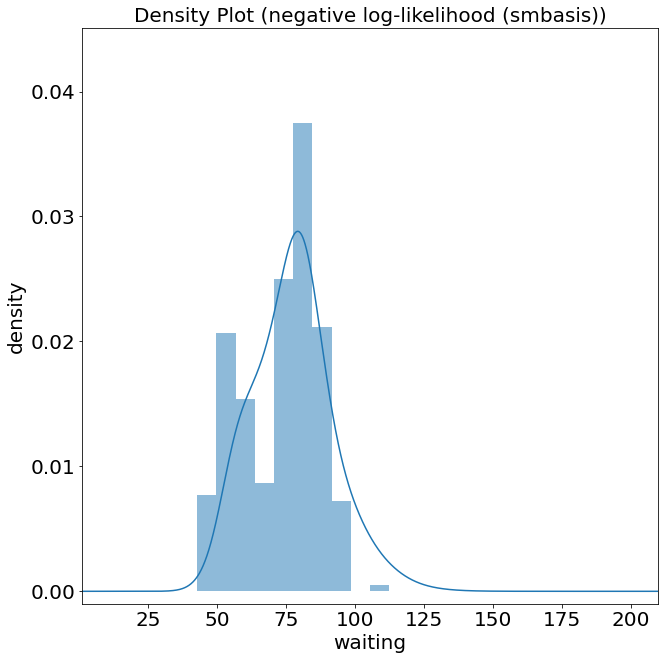

loss_val=-0.0864266149250756
0.4550878122957196
**************************************************
log penalty = -0.5
start time = 19:17:27
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.2010174026847341, Relative Error = 0.3893040866196898
Iter = 3, GradNorm = 0.17345694671333572, Relative Error = 0.3359286176529811
Iter = 4, GradNorm = 0.1794570545021809, Relative Error = 0.3475488378486401
Iter = 5, GradNorm = 0.18636355786062733, Relative Error = 0.3609244458596175
Iter = 6, GradNorm = 0.20770077661125635, Relative Error = 0.40224756687191077
Iter = 7, GradNorm = 0.22081149474075362, Relative Error = 0.4276386826567321
Iter = 8, GradNorm = 0.24477993787293834, Relative Error = 0.4740576132400978
Iter = 9, GradNorm = 0.27090456209914304, Relative Error = 0.5246523519882451
Iter = 10, GradNorm = 0.30277384093630044, Relative Error = 0.586372582790282
Iter = 11, GradNorm = 0.376450460395597, Relative Error = 0.7290597763404459
Iter = 12, GradNorm 

KeyboardInterrupt: 

In [36]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.2, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05 / np.sqrt(200) * np.sqrt(len(grid_points))
)

for log_pen_param in [-1., -0.5, 0.]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    print(f'loss_val={loss_val}')
    
    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = -0.5
start time = 19:19:38
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.2742357457189654, Relative Error = 0.5311037506191951
Iter = 3, GradNorm = 0.16984020980187056, Relative Error = 0.32892419693588565
Iter = 4, GradNorm = 0.1059151510386456, Relative Error = 0.20512254453389075
Iter = 5, GradNorm = 0.07379928921907832, Relative Error = 0.14292476421892145
Iter = 6, GradNorm = 0.0715277857684804, Relative Error = 0.1385256148702683
Iter = 7, GradNorm = 0.053242941466089835, Relative Error = 0.10311393152815738
Iter = 8, GradNorm = 0.05332513146281605, Relative Error = 0.10327310631191955
Iter = 9, GradNorm = 0.05870027534438843, Relative Error = 0.11368297854843844
Iter = 10, GradNorm = 0.044620222761070326, Relative Error = 0.08641458318914383
Iter = 11, GradNorm = 0.058685490132471846, Relative Error = 0.1136543444931587
Iter = 12, GradNorm = 0.03453801115585952, Relative Error

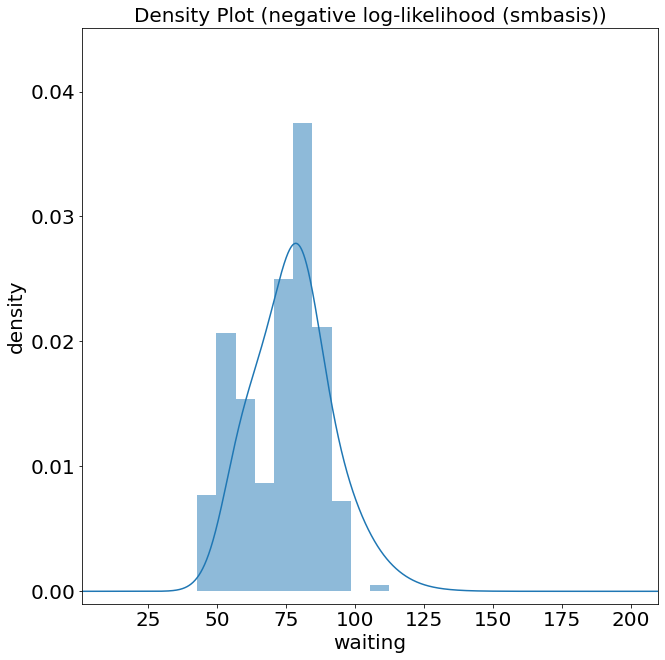

loss_val=-0.05761166668767028
0.29646040926303285
**************************************************
log penalty = 0.0
start time = 19:20:36
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.19508145510568936, Relative Error = 0.3778081234860568
Iter = 3, GradNorm = 0.12380738646050089, Relative Error = 0.23977387459517016
Iter = 4, GradNorm = 0.0804942451264587, Relative Error = 0.1558906749294957
Iter = 5, GradNorm = 0.051861356944080464, Relative Error = 0.10043826020196725
Iter = 6, GradNorm = 0.0479215893156105, Relative Error = 0.09280823604679095
Iter = 7, GradNorm = 0.03438559543666427, Relative Error = 0.06659350208269987
Iter = 8, GradNorm = 0.04170506179625553, Relative Error = 0.08076888256024606
Iter = 9, GradNorm = 0.061389468446638784, Relative Error = 0.118891054319159
Iter = 10, GradNorm = 0.0634195707733942, Relative Error = 0.12282268969752243
Iter = 11, GradNorm = 0.0718657354724516, Relative Error = 0.1391801114415639
Iter = 12, G

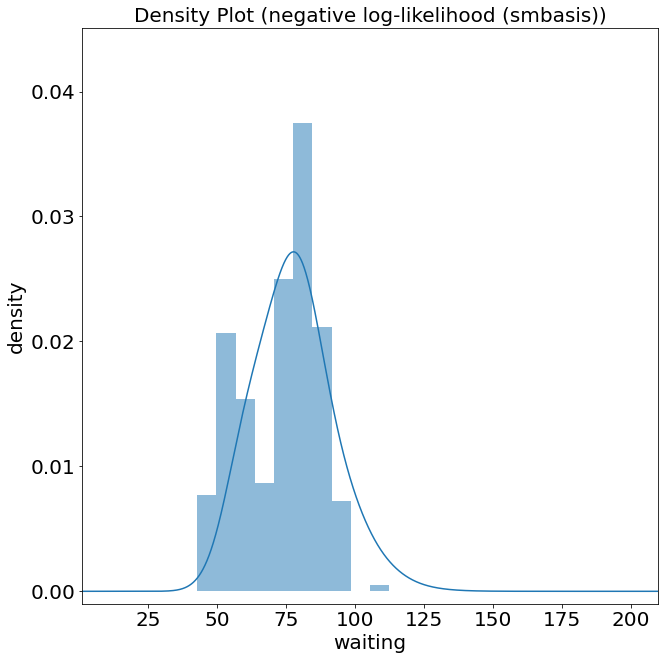

loss_val=-0.03860565376546747
0.19124110413111534


In [37]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.1, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05 / np.sqrt(200) * np.sqrt(len(grid_points))
)

for log_pen_param in [-0.5, 0.]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    print(f'loss_val={loss_val}')
    
    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = 0.5
start time = 19:21:27
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.23034872015005387, Relative Error = 0.4461091273906979
Iter = 3, GradNorm = 0.13423500746361933, Relative Error = 0.2599687204941696
Iter = 4, GradNorm = 0.07811575966249774, Relative Error = 0.15128433687757217
Iter = 5, GradNorm = 0.05580459480864201, Relative Error = 0.1080750050543267
Iter = 6, GradNorm = 0.056392685237139945, Relative Error = 0.10921394130590706
Iter = 7, GradNorm = 0.04268268232423488, Relative Error = 0.08266220951414449
Iter = 8, GradNorm = 0.047650998387441086, Relative Error = 0.09228419109977819
Iter = 9, GradNorm = 0.05644701654867181, Relative Error = 0.10931916304953856
Iter = 10, GradNorm = 0.04652393173166146, Relative Error = 0.09010143652665327
Iter = 11, GradNorm = 0.05883783926594339, Relative Error = 0.11394939427223906
Iter = 12, GradNorm = 0.04073722653890287, Relative Erro

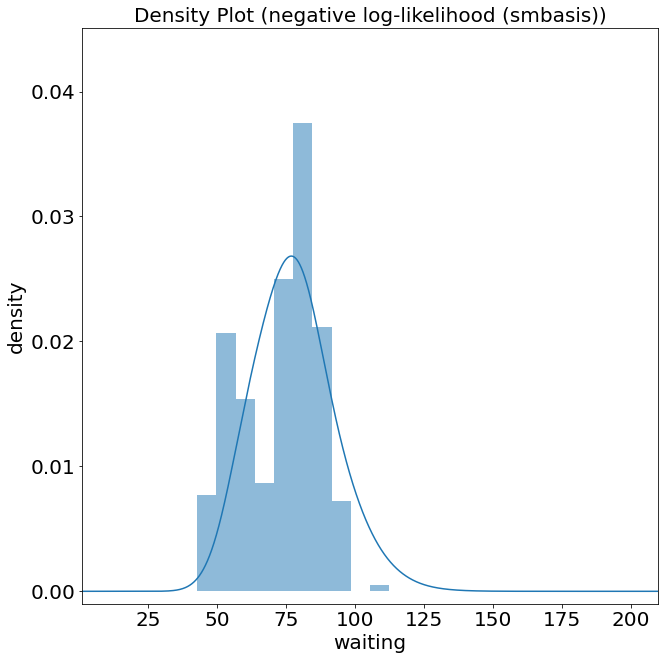

loss_val=-0.024367389509068586
0.11900223418901486
**************************************************
log penalty = 1.0
start time = 19:22:19
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.22698109457829727, Relative Error = 0.4395871527766593
Iter = 3, GradNorm = 0.22477654485720605, Relative Error = 0.4353176706118582
Iter = 4, GradNorm = 0.24331063526185923, Relative Error = 0.4712120610474293
Iter = 5, GradNorm = 0.26861316928347684, Relative Error = 0.5202146835313062
Iter = 6, GradNorm = 0.30245708766506285, Relative Error = 0.5857591366841439
Iter = 7, GradNorm = 0.3461176370032239, Relative Error = 0.6703151505137739
Iter = 8, GradNorm = 0.42551741273170657, Relative Error = 0.8240862009549337
Iter = 9, GradNorm = 0.5238402500356245, Relative Error = 1.0145049500743355
Iter = 10, GradNorm = 0.6374658707558487, Relative Error = 1.2345601189318203
Iter = 11, GradNorm = 0.7952252178506513, Relative Error = 1.5400876887153336
Iter = 12, GradNor

KeyboardInterrupt: 

In [38]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.05, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05 / np.sqrt(200) * np.sqrt(len(grid_points))
)

for log_pen_param in [0.5, 1.]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    print(f'loss_val={loss_val}')
    
    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

**************************************************
log penalty = 1.0
start time = 19:23:39
Iter = 1, GradNorm = 0.5163506102136233, Relative Error = 1.0
Iter = 2, GradNorm = 0.31545090984812807, Relative Error = 0.6109238637630747
Iter = 3, GradNorm = 0.21040586360400984, Relative Error = 0.4074864238408884
Iter = 4, GradNorm = 0.14358260915243945, Relative Error = 0.2780719269277842
Iter = 5, GradNorm = 0.10256474369374141, Relative Error = 0.1986339159186983
Iter = 6, GradNorm = 0.09522970392576233, Relative Error = 0.18442837491053635
Iter = 7, GradNorm = 0.07172425315570667, Relative Error = 0.13890610708493806
Iter = 8, GradNorm = 0.061716262746092244, Relative Error = 0.1195239465690941
Iter = 9, GradNorm = 0.06364450752347571, Relative Error = 0.12325831763255758
Iter = 10, GradNorm = 0.04186741241514404, Relative Error = 0.08108330190182744
Iter = 11, GradNorm = 0.06422464127550719, Relative Error = 0.12438184443887135
Iter = 12, GradNorm = 0.03772927138830693, Relative Error =

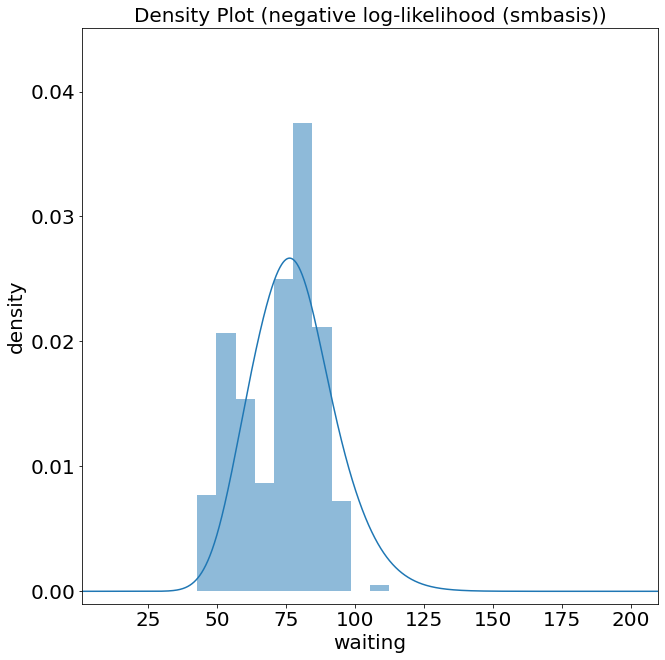

loss_val=-0.014862425887403972
0.07298064699718637


In [39]:
waiting = waiting.reshape(-1, 1)

gdalgo_params = negloglik_optalgo_params(
    start_pt = np.zeros((grid_points.shape[0], 1)), 
    step_size = 0.02, 
    max_iter = 50, 
    rel_tol = 1e-5, 
    abs_tol = 0.05 / np.sqrt(200) * np.sqrt(len(grid_points))
)

for log_pen_param in [1.]: 
    
    print('*' * 50)
    print(f'log penalty = {log_pen_param}')
    
    np.random.seed(seed_no)
    print(f'start time = {dt.now().strftime("%H:%M:%S")}')
    nll_pen_coef = nll_pen.coef(
        data = waiting, 
        lambda_param = np.exp(log_pen_param), 
        optalgo_params = gdalgo_params, 
        batchmc_params = bmc_params, 
        batch_mc = True, 
        print_error = True
    )
    print(f'end time = {dt.now().strftime("%H:%M:%S")}')
    
    plot_params = plot_density_1d_params(xlimit, ylimit, plot_pts_cnt=plot_pts_cnt)
    
    # visualize density estimate
    den_vals = plot_density_1d(
        data = waiting, 
        kernel_function = nll_pen.kernel_function, 
        base_density = base_density, 
        basis_type = 'grid_points', 
        coef = nll_pen_coef, 
        normalizing = True, 
        method = 'negative log-likelihood (smbasis)', 
        x_label = 'waiting',
        grid_points = grid_points, 
        save_plot = False, 
        save_dir = None, 
        save_filename = None, 
        plot_kwargs = plot_params)
    
    kernel_function_grid = GaussianPoly2(
        data=grid_points.reshape(-1, 1),
        r1=1.,
        r2=0.,
        c=0.,
        bw=bw)

    gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

    # compute value of loss functional
    loss_val = nll_pen.eval_loss_function(
        new_data=waiting, 
        coef=nll_pen_coef, 
        batchmc_params=bmc_params, 
        batch_mc=True)
    print(f'loss_val={loss_val}')
    
    print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())
    
    file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
    np.save(ml_folder + file_name_coef, nll_pen_coef)

    file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
    np.save(ml_folder + file_name_den, den_vals['den_vals'])
    

In [ ]:
plot_params = plot_density_1d_params((1., 310.), ylimit, plot_pts_cnt=plot_pts_cnt)
    
# visualize density estimate
den_vals = plot_density_1d(
    data = waiting, 
    kernel_function = nll_pen.kernel_function, 
    base_density = base_density, 
    basis_type = 'grid_points', 
    coef = nll_pen_coef, 
    normalizing = True, 
    method = 'negative log-likelihood (smbasis)', 
    x_label = 'waiting',
    grid_points = grid_points, 
    save_plot = False, 
    save_dir = None, 
    save_filename = None, 
    plot_kwargs = plot_params)

kernel_function_grid = GaussianPoly2(
    data=grid_points.reshape(-1, 1),
    r1=1.,
    r2=0.,
    c=0.,
    bw=bw)

gram_grid = kernel_function_grid.kernel_gram_matrix(grid_points.reshape(-1, 1))

print(np.sqrt(nll_pen_coef.T @ gram_grid @ nll_pen_coef).item())

file_name_coef = f'/logpenparam={log_pen_param}-coef.npy'
np.save(ml_folder + file_name_coef, nll_pen_coef)

file_name_den = f'/logpenparam={log_pen_param}-densityvals-newdata.npy'
np.save(ml_folder + file_name_den, den_vals['den_vals'])


In [ ]:
ml_folder

In [ ]:
from matplotlib import gridspec

In [ ]:
ml_folder = (f'../data/PenML-ContamData={contam_pt}-bw={bw}-' + 
             f'kernel={kernel_type}-plotdomain={xlimit}-plotcnts={plot_pts_cnt}-' + 
             f'seed={seed_no}')

sm_folder = (f'../data/PenSM-FinKEF-ContamData={contam_pt}-bw={bw}-kernel={kernel_type}-' + 
             f'plotdomain={xlimit}-plotcnts={plot_pts_cnt}')

new_data = np.linspace(xlimit[0], xlimit[1], plot_pts_cnt)

In [ ]:
fig = plt.figure(constrained_layout=False)

fig.set_figheight(20)
fig.set_figwidth(50)
ncols = 5
nrows = 2
linewidth = 4.0
var_name = 'waiting'

label_fontsize = 35
tick_fontsize = 30
info_fontsize = 40

spec = gridspec.GridSpec(ncols=ncols, nrows=nrows, figure=fig)
ml_logpen_list1 = [-np.inf, -20., -15., -10., -9.]
ml_logpen_list2 = [-6., -4.5, -3., -2., 1.]

for i in range(ncols): 
    
    ax = fig.add_subplot(spec[0, i])
    file_name_den = f'/logpenparam={ml_logpen_list1[i]}-densityvals-newdata.npy'
    sm_den = np.load(ml_folder + file_name_den)

    ax.plot(new_data.flatten(), sm_den.flatten(), color = 'tab:red', linewidth = linewidth)
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    
    if i == 0: 
        ax.set_ylabel(r'density', fontsize = label_fontsize)
    ax.set_xlim(xlimit)
    ax.set_ylim(ylimit)
    # ax.axvline(108., 0, 1, ls = '--', color = 'tab:purple', alpha = 0.5)
    # ax.tick_params(axis = 'both', labelsize = fontsize)
    # ax.ticklabel_format(axis = 'y', style = 'sci', scilimits = scilimits)
    ax.tick_params(axis = 'both', labelsize = tick_fontsize)
    ax.set_xticks([])
    if i != 0: 
        ax.set_yticks([])
    #ax.set_xlabel(var_name, fontsize = fontsize)

    if i == 0: 
        info = r"$\lambda$=0"
    else: 
        info = r"$\lambda$=exp({bw})".format(bw = ml_logpen_list1[i])

    ax.text(0.02, 0.978,
            info,
            fontsize = info_fontsize,
            multialignment = 'left',
            horizontalalignment = 'left',
            verticalalignment = 'top',
            transform = ax.transAxes,
            bbox = {'facecolor': 'none',
                    'boxstyle': 'Round, pad=0.2'})

for i in range(ncols): 
    
    ax = fig.add_subplot(spec[1, i])
    file_name_den = f'/logpenparam={ml_logpen_list2[i]}-densityvals-newdata.npy'
    ml_den = np.load(ml_folder + file_name_den)

    ax.plot(new_data.flatten(), ml_den.flatten(), color = 'tab:red', linewidth = linewidth)
    plt.hist(waiting, bins='fd', density = True, alpha = 0.3, color = 'tab:green')
    
    if i == 0: 
        ax.set_ylabel(r'density', fontsize = label_fontsize)
    ax.set_xlim(xlimit)
    ax.set_ylim(ylimit)
    # ax.axvline(108., 0, 1, ls = '--', color = 'tab:purple', alpha = 0.5)
    # ax.tick_params(axis = 'both', labelsize = fontsize)
    # ax.ticklabel_format(axis = 'y', style = 'sci', scilimits = scilimits)
    ax.tick_params(axis = 'both', labelsize = tick_fontsize)
    ax.set_xlabel(var_name, fontsize = label_fontsize)
    if i != 0: 
        ax.set_yticks([])
    #ax.set_xlabel(var_name, fontsize = fontsize)

    info = r"$\lambda$=exp({bw})".format(bw = ml_logpen_list2[i])

    ax.text(0.015, 0.988,
            info,
            fontsize = info_fontsize,
            multialignment = 'left',
            horizontalalignment = 'left',
            verticalalignment = 'top',
            transform = ax.transAxes,
            bbox = {'facecolor': 'none',
                    'boxstyle': 'Round, pad=0.2'})


plt.tight_layout()

# plt.savefig('../plots/ML-only-density-comparison.pdf')